# Self-Supervised Vision

Labels are the bottleneck of supervised vision. Self-supervised pretraining removes them: learn visual features from 100M unlabelled images, fine-tune on 10k labelled ones.

## Problem Definition

Can we **pretrain on cheap unlabelled data** — YouTube frames, web crawls, webcam footage, satellite sweeps — and then **fine-tune on a small labelled set**?

The conceptual shift is that the pretext task — the thing the model is trained to do — does not have to be the downstream task. What matters is that it forces the model to learn useful features. Predict the colour of grayscale images, rotate images and ask the model to classify the rotation, mask patches and reconstruct them — all have worked. The three approaches that scale are **contrastive learning, teacher-student distillation, and masked reconstruction.**

## Basic Concept


### Three families

```mermaid
flowchart LR
    A["Contrastive<br/>SimCLR, MoCo, CLIP"] --> AT["positive pairs<br/>(same image, 2 augs)<br/>pulled together,<br/>negatives pushed apart"]
    B["Teacher-student<br/>DINO, BYOL, iBOT"] --> BT["student predicts<br/>teacher's output;<br/>teacher is EMA of student"]
    C["Masked reconstruction<br/>MAE, BEiT, SimMIM"] --> CT["mask 75% of patches;<br/>reconstruct pixel or<br/>token targets"]

    style A fill:#dbeafe,stroke:#2563eb
    style B fill:#fef3c7,stroke:#d97706
    style C fill:#dcfce7,stroke:#16a34a
```

### Constrastive Learning (SimCLR)

Take one image, apply two random augmentations, get two views. 
"these two embeddings should be close" and "this embedding should be far from every other image's embeddings in the batch."

```
Loss for positive pair (z_i, z_j) among 2N view per batch:

L_ij = -log(
        exp(sim(z_i, z_j) / tau) /
        sum(exp(sim(z_i, z_k) / tau))
    )

sim = cosine similarity
tau = temperature (0.1 standard)
```

InfoNCE loss. Batch size matters

### Teacher-student (DINO)

Two networks with the same architecture: student and teacher. The teacher is an exponential moving average (EMA) of the student's weights. Both see augmented views of the image. The student's output is trained to match the teacher's — no explicit negatives.

```

loss = CE(student_output(view_1), teacher_output(view_2))
      + CE(student_output(view_2), tacher_output(view_1))

teacher_weighs = m * teachers_weights + (1 - m) * student_weights (m ~ 0.996)

```

Why it does not collapse to "predict a constant": the teacher's output is centred (subtract per-dimension mean) and sharpened (divide by small temperature). Centering prevents one dimension from dominating; sharpening prevents output collapse to uniform.

### Masked reconstruction (MAE)

Mask 75% of patches of a ViT input. Pass only the visible 25% through the encoder. A small decoder receives the encoder's output plus mask tokens at masked positions, and is trained to reconstruct the pixels of the masked patches.

```
Encoder: visible 25% of patches --> features
Decoder: feature + mask tokens at masked poistions --> reconstructed pixels
Loss: MSE between reconstructed and original pixels on masked patches only
```


Key design choices that make MAE work:

- **75% mask ratio** — high. Forces the encoder to learn semantic features; reconstructing 25% would be near-trivial (neighbouring pixels are so correlated that a CNN could nail it).
- **Asymmetric encoder/decoder** — the big ViT encoder only sees visible patches; a small decoder (8-layer, 512-dim) handles reconstruction. 3x faster pretraining than naive BEiT.
- **Pixel-space reconstruction target** — simpler than BEiT's tokenised target and works better on ViT.

After pretraining, discard the decoder. The encoder is the feature extractor.

# Build your Own

## Two-view augmentation pipeline

In [2]:
import torch
import torchvision.transforms as T

two_view_train = lambda: T.Compose([
    T.RandomResizedCrop(96, scale=(0.2, 1.0)),
    T.RandomHorizontalFlip(),
    T.ColorJitter(0.4, 0.4, 0.4, 0.1),
    T.RandomGrayscale(p=0.2),
    T.ToTensor(),
])

class TwoViewDataset(torch.utils.data.Dataset):
    def __init__(self, base):
        self.base = base
        self.aug = two_view_train()

    def __len__(self):
        return len(self.base)

    def __getitem__(self, i):
        img, _ = self.base[i]
        v1 = self.aug(img)
        v2 = self.aug(img)
        return v1, v2

## Visualize two-view augmentation

Same image → two independent draws of `two_view_train`; contrastive methods treat these as a positive pair.

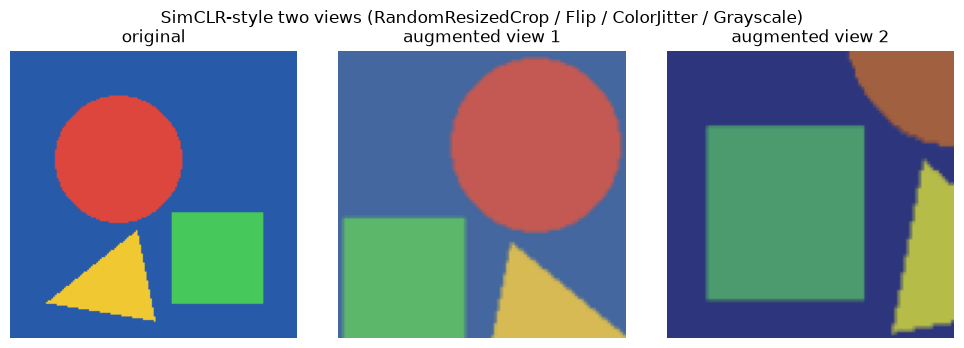

In [3]:
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

# Synthetic scene so the demo needs no external dataset
img = Image.new("RGB", (160, 160), (40, 90, 170))
draw = ImageDraw.Draw(img)
draw.ellipse([25, 25, 95, 95], fill=(220, 70, 60))
draw.rectangle([90, 90, 140, 140], fill=(70, 200, 90))
draw.polygon([(20, 140), (70, 100), (80, 150)], fill=(240, 200, 50))

aug = two_view_train()
view1, view2 = aug(img), aug(img)  # two independent random augs

fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))
axes[0].imshow(img)
axes[0].set_title("original")
axes[1].imshow(view1.permute(1, 2, 0).clamp(0, 1).numpy())
axes[1].set_title("augmented view 1")
axes[2].imshow(view2.permute(1, 2, 0).clamp(0, 1).numpy())
axes[2].set_title("augmented view 2")
for ax in axes:
    ax.axis("off")
plt.suptitle("SimCLR-style two views (RandomResizedCrop / Flip / ColorJitter / Grayscale)")
plt.tight_layout()
plt.show()


## InfoNCE Loss

In [ ]:
import torch.nn.functional as F

def info_nce(z1, z2, tau=0.1):
    N, D = z1.shape
    z = torch.cat([z1, z2], dim=0)
    sim = z @ z.T / tau

    mask = torch.eye(2 * N, dtype=torch.bool, device=z.device)
    sim = sim.masked_fill(mask, -float("inf"))

    targets = torch.cat([
        torch.arange(N, 2 * N),
        torch.arange(0, N)
    ]).to(z.device)

    # PyTorch 会对 sim 的每一行做 log_softmax，再取 targets[i] 那一类的负对数似然
    return F.cross_entropy(sim, targets)

## Santiy check InfoNCE

In [10]:
z1 = F.normalize(torch.randn(16, 32), dim=-1)
z2 = z1.clone()
loss_same = info_nce(z1, z2, tau=0.1).item()
z2_random = F.normalize(torch.randn(16, 32), dim=-1)
loss_random = info_nce(z1, z2_random, tau=0.1).item()
print(f"InfoNCE with identical pairs:  {loss_same:.3f}")
print(f"InfoNCE with random pairs:     {loss_random:.3f}")

InfoNCE with identical pairs:  0.006
InfoNCE with random pairs:     4.466


## MAE-style masking

In [11]:
def random_mask_indices(num_patches, masked_ratio=0.75, seed=0):
    g = torch.Generator().manual_seed(seed)
    n_keep = int(num_patches * (1 - masked_ratio))
    perm = torch.randperm(num_patches, generator=g)
    visible = perm[:n_keep]
    masked = perm[n_keep:]
    return visible.sort().values, masked.sort().values

num_patches = 16 * 16
visible, masked = random_mask_indices(num_patches, masked_ratio=0.75, seed=0)
print(f"visible: {visible}")
print(f"masked: {masked}")



visible: tensor([  0,   2,   7,  11,  13,  20,  38,  40,  47,  50,  55,  56,  57,  59,
         61,  65,  71,  75,  77,  80,  81,  87,  91, 102, 105, 113, 114, 119,
        125, 130, 133, 137, 138, 140, 147, 149, 154, 156, 157, 158, 159, 161,
        165, 172, 174, 183, 186, 193, 198, 200, 204, 209, 210, 211, 214, 222,
        225, 232, 239, 240, 242, 245, 246, 250])
masked: tensor([  1,   3,   4,   5,   6,   8,   9,  10,  12,  14,  15,  16,  17,  18,
         19,  21,  22,  23,  24,  25,  26,  27,  28,  29,  30,  31,  32,  33,
         34,  35,  36,  37,  39,  41,  42,  43,  44,  45,  46,  48,  49,  51,
         52,  53,  54,  58,  60,  62,  63,  64,  66,  67,  68,  69,  70,  72,
         73,  74,  76,  78,  79,  82,  83,  84,  85,  86,  88,  89,  90,  92,
         93,  94,  95,  96,  97,  98,  99, 100, 101, 103, 104, 106, 107, 108,
        109, 110, 111, 112, 115, 116, 117, 118, 120, 121, 122, 123, 124, 126,
        127, 128, 129, 131, 132, 134, 135, 136, 139, 141, 142, 143, 144, 145